# Introduction to NoSQL databases

This introduction walks through the CRUD (create, read, update, delete) operations on `mongodb`.

## MongoDB

MongoDB is a document-oriented NoSQL database. It stores data in JSON-like documents with dynamic schemas, making the integration of data in certain types of applications easier and faster.

We will be connecting to a MongoDB cluster hosted on MongoDB Atlas. MongoDB Atlas is a cloud database service that allows you to host MongoDB databases on the cloud.

Prerequisite:
The learner is required to set up an account on MongoDB [here](https://www.mongodb.com/) and set up a (free tier) cluster. Please take note of the cluster URL and credentials (DB username and DB password) required to access the cluster. If necessary, you can refer to the screenshots below:

[step 0](../assets/mongodb_setup_createCluster.png) (Choose **free** cluster and 'Create Deployment')

[step 1](../assets/mongodb_setup_password.png) (When prompted, set up your DB username and DB password - note it down! Note this is different from your login username and password.)

[step 2](../assets/mongodb_setup_drivers.png) (Click 'Drivers' to see how to access using python)

[step 3](../assets/mongodb_setup_code.png) (Copy and paste the code into a cell below - note you have to input your password as well)

We will be using the `pymongo` library to connect to the MongoDB database. 

Note that to run the command `python -m pip install "pymongo[srv]"` in a Jupyter notebook cell, you have to add an exclamation mark as such: `!python -m pip install "pymongo[srv]"`


In [48]:
# Copy and paste the pip install step from step 3 above into this cell below the line
# ------------------------------------------------------------------------------

!python -m pip install "pymongo[srv]"

## Connecting to MongoDB

#### **Connection Code**

In [49]:
# Copy and paste the connection code from step 3 above into this cell below the line
# ------------------------------------------------------------------------------

# sometimes the uri below did not include password, it has a place holder <password>
# make sure you complete uri with password
# delete the following when .env file are setup.

# To connect Python to MongoDB Atlas, you need:
# 1. Cluster must be running
# 2. Database user must exist
# 3. Your current IP address must be allowed
# 4. Python must use the correct connection string

# MongoClient = the Python object that talks to MongoDB
from pymongo.mongo_client import MongoClient
# ServerApi = tells MongoDB which server API version to use
from pymongo.server_api import ServerApi
# quote_plus = makes password safe for URL use
from urllib.parse import quote_plus
# getpass = asks you for password without showing it
import getpass
import certifi

import pandas as pd

# replace with your actual DB username
# this is the actual username string
username = "pds_user"   
# dont save password here,ask user to input
password = quote_plus(getpass.getpass("Enter MongoDB password:"))


# test connection to mongoDB and list database names

# replace with your real Atlas cluster URL
# This is the actual address of your MongoDB cluster
cluster_url = "cluster0.puxevha.mongodb.net"  

# Build the full connection address to create the final connection string
# uri = database address + username + password + cluster location
# mongodb+srv://...         = where the database lives
# ?retryWrites=true         = if writing fails briefly, try again
# &w=majority               = only count a write as successful when most database copies agree
# &appName=Cluster0         = label this connection as coming from app/cluster name Cluster0
uri = f"mongodb+srv://{username}:{password}@{cluster_url}/?retryWrites=true&w=majority&appName=Cluster0"

# Create the client to create a MongoDB connection object using the uri
# client is now your Python handle to MongoDB. itt does not mean 
# we have created a database yet. It just means Python knows how to talk to the MongoDB cluster
# Use language version 1 when Python and MongoDB talk to each other.
client = MongoClient(uri, server_api=ServerApi("1"))

#ping test
try:
    client.admin.command("ping")
    print("Connected successfully to MongoDB.")
    print(client.list_database_names())

except Exception as e:
    print("MongoDB connection failed:")
    print(e)



KeyboardInterrupt: Interrupted by user

In [ ]:
'''
# to test MongoDB
# it does not exist yet, MongoDB will create the db  when you insert data
db = client["test_db"]

# This chooses a collection called 'items' inside 'test_db'
collection = db["items"]

# creates one MongoDB document, a document is like a row, but in dictionary/JSON style.
sample_items = {
    "name": "item A",
    "description": "description of item",
    "status": "connected",
    "tool": "MongoDB Atlas"
}

# Unlike SQL, MongoDB documents can be more flexible. 
# Not every document in the same collection needs to have exactly the same shape
# although keeping things consistent is better


# this inserts the document sample_items into MongoDB.
collection.delete_many({})
result = collection.insert_one(sample_items)

# MongoDB automatically gives every document an _id.
print("Inserted document ID:", result.inserted_id)

# Find documents inside the items collection
# {} means no filter
# {"_id": 0} hides the Mongo id
# Get all documents from items, but don’t show _id, and turn the result into a Python list.
# Why list()? Because MongoDB gives back a cursor, which is like a lazy stream of results. 
# list() forces it into a normal Python list you can inspect.
docs = list(collection.find({}, {"_id": 0}))

# converts the list of MongoDB documents into a pandas DataFrame
df = pd.DataFrame(docs)

display(df)
'''

<span style="color: red"><b>IMPORTANT</b></span>

<span style="color: red"><b>Your connection secrets including the password is yours. Do not share the secrets above. Do not sync the information above to your public repository. To safely keep your password and connection string locally. Please run the following cell.</b></span>

> Please refer to the end of [MongoDB installation guide](https://drive.google.com/file/d/1pMF-6O-TilA4wEhwng0k2sZ8TUpoKVil/view?usp=sharing) for troubleshooting and resetting password.

#### **Saving Connection Secrets Locally Using dotenv (Run Once)**

Run the following cell to save your secrets to a local dotenv file:

- Please ensure that your connection is successful in the previous cell
- You only need to run once

In [ ]:
# Cell: Export MongoDB configuration to .env file
import os

# Check if uri exists and is not null
try:
    # 1. Check if 'uri' is defined in the current scope (`locals()`)
    # 2. Check if the value of 'uri' is not empty (e.g., not None, not an empty string)
    if 'uri' not in locals() or not uri:
        # If either condition fails, raise a custom exception immediately.
        # This will be caught by the outer 'except' block.
        raise ValueError("MongoDB uri is not defined or is empty. Please run the connection code cell above.")

    # Create .env file with MongoDB configuration
    env_content = f"""# MongoDB Configuration
# Auto-generated from notebook
# This file will not be synced to Github
# To save reconfiguration effort, please make a copy to somewhere safe
MONGODB_URI='{uri}'
"""

    with open('../.env', 'w') as f:
        f.write(env_content)

    print("✅ Configuration exported to .env file")

except ValueError as e:
    print(f"❌ Error: {e}")



✅ Configuration exported to .env file


You should see a file called `.env`, similar to the screenshot below:

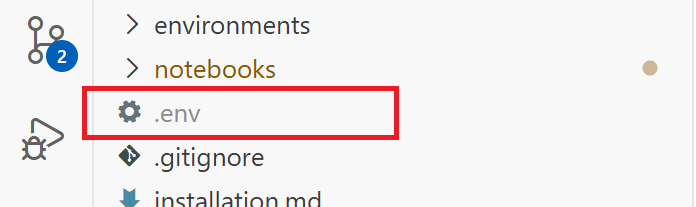

#### **Testing MongoDB Connection Using dotenv**

**You can start from here if you have already setup the env file.**

In [ ]:
import pymongo
import os
from dotenv import load_dotenv
from pymongo.mongo_client import MongoClient
from pymongo.server_api import ServerApi

# Load environment variables from .env file
load_dotenv()
MONGODB_URI = os.getenv('MONGODB_URI')
client = MongoClient(MONGODB_URI, server_api=ServerApi('1'))
# Send a ping to confirm a successful connection
try:
    client.admin.command('ping')
    print("Pinged your deployment. You successfully connected to MongoDB!")
    print(client.list_database_names())
except Exception as e:
    print(e)


Pinged your deployment. You successfully connected to MongoDB!
['admin', 'local']


<span style="color: red"><b>IMPORTANT</b></span>

<span style="color: red"><b>If your connection is good using dotenv. Please remove what you have pasted previously on the `Connection Code`. </b></span>

If you have connected to the cluster successfully above, you can skip the below cell. Else, set up the connection to the cluster (replace <DB-USERNAME>, <DB-PASSWORD>, <CLUSTER-NAME> below with your own)

In [ ]:
# client = pymongo.MongoClient("mongodb+srv://<DB-USERNAME>:<DB-PASSWORD>@<CLUSTER-NAME>.mongodb.net/test?retryWrites=true&w=majority")

### Accessing Sample Database

A cluster can host multiple databases. List all databases in the cluster:

In [ ]:
print(client.list_database_names())
# MongoDB is connected, and the movie sample database exists.

['sample_mflix', 'admin', 'local']


### Read

You can access a database using attribute style access:

In [65]:

db = client.sample_mflix

# Use the sample_mflix database and call it db

# client = whole MongoDB cluster/building
# sample_mflix = movie database
# db = shortcut name for that db

A collection is a group of documents stored in MongoDB, and can be thought of as roughly the equivalent of a table in a relational database.

List all collections in the database:

In [66]:
print(db.list_collection_names())

# db -> database
# collection -> tables
# document -> row
# field -> column

['theaters', 'users', 'movies', 'embedded_movies', 'sessions', 'comments']


Let's assign the `movies` collection to a variable:

In [67]:
movies = db.movies

# From the sample_mflix database, grab the movies collection and store it in a Python variable called movies

Data in MongoDB is represented (and stored) using JSON-style documents. In PyMongo we use dictionaries to represent documents.

The most basic type of query that can be performed in MongoDB is `find_one()`. This method returns a single document matching a query (or None if there are no matches). You can also omit the query to get the first document from the collection:

In [68]:
movies.find_one()

# MongoDB idea	Python-looking form
# collection    group of documents
# document	    dictionary
# field	        key
# field value	value

{'_id': ObjectId('573a1390f29313caabcd42e8'),
 'plot': 'A group of bandits stage a brazen train hold-up, only to find a determined posse hot on their heels.',
 'genres': ['Short', 'Western'],
 'runtime': 11,
 'cast': ['A.C. Abadie',
  "Gilbert M. 'Broncho Billy' Anderson",
  'George Barnes',
  'Justus D. Barnes'],
 'poster': 'https://m.media-amazon.com/images/M/MV5BMTU3NjE5NzYtYTYyNS00MDVmLWIwYjgtMmYwYWIxZDYyNzU2XkEyXkFqcGdeQXVyNzQzNzQxNzI@._V1_SY1000_SX677_AL_.jpg',
 'title': 'The Great Train Robbery',
 'fullplot': "Among the earliest existing films in American cinema - notable as the first film that presented a narrative story to tell - it depicts a group of cowboy outlaws who hold up a train and rob the passengers. They are then pursued by a Sheriff's posse. Several scenes have color included - all hand tinted.",
 'languages': ['English'],
 'released': datetime.datetime(1903, 12, 1, 0, 0),
 'directors': ['Edwin S. Porter'],
 'rated': 'TV-G',
 'awards': {'wins': 1, 'nominations': 0, 

> Get the first document from the `comments` collection.

In [69]:
comments = db.comments
comments.find_one()


{'_id': ObjectId('5a9427648b0beebeb69579e7'),
 'name': 'Mercedes Tyler',
 'email': 'mercedes_tyler@fakegmail.com',
 'movie_id': ObjectId('573a1390f29313caabcd4323'),
 'text': 'Eius veritatis vero facilis quaerat fuga temporibus. Praesentium expedita sequi repellat id. Corporis minima enim ex. Provident fugit nisi dignissimos nulla nam ipsum aliquam.',
 'date': datetime.datetime(2002, 8, 18, 4, 56, 7)}

You can pass a query to the `find_one()` method to filter the results to only include documents that match the query criteria. The first argument to the find() method is a document containing the query criteria. To specify an equality match, use a document (dictionary) with the specific field and value: 

In [70]:
movies.find_one({'title': 'Traffic in Souls'})

{'_id': ObjectId('573a1390f29313caabcd4eaf'),
 'plot': 'A woman, with the aid of her police officer sweetheart, endeavors to uncover the prostitution ring that has kidnapped her sister, and the philanthropist who secretly runs it.',
 'genres': ['Crime', 'Drama'],
 'runtime': 88,
 'cast': ['Jane Gail', 'Ethel Grandin', 'William H. Turner', 'Matt Moore'],
 'num_mflix_comments': 1,
 'poster': 'https://m.media-amazon.com/images/M/MV5BYzk0YWQzMGYtYTM5MC00NjM2LWE5YzYtMjgyNDVhZDg1N2YzXkEyXkFqcGdeQXVyMzE0MjY5ODA@._V1_SY1000_SX677_AL_.jpg',
 'title': 'Traffic in Souls',
 'lastupdated': '2015-09-15 02:07:14.247000000',
 'languages': ['English'],
 'released': datetime.datetime(1913, 11, 24, 0, 0),
 'directors': ['George Loane Tucker'],
 'rated': 'TV-PG',
 'awards': {'wins': 1, 'nominations': 0, 'text': '1 win.'},
 'year': 1913,
 'imdb': {'rating': 6.0, 'votes': 371, 'id': 3471},
 'countries': ['USA'],
 'type': 'movie',
 'tomatoes': {'viewer': {'rating': 3.0, 'numReviews': 85, 'meter': 57},
  'dvd

You can also query by `_id` which is the unique identifier (think of it as a primary key) for each document in a collection. However, it is an `ObjectId` hence you need to convert it from a string:

In [71]:
# This imports the tool that lets Python understand MongoDB’s special ID type.
from bson.objectid import ObjectId

In [72]:
# movies.find_one({'_id': '573a1390f29313caabcd4eaf'}) beceomes searching for _id as a string. so you need objectID
movies.find_one({'_id': ObjectId("573a1390f29313caabcd4eaf")})


#_id = unique document barcode
# ObjectId = special MongoDB barcode type
# find_one({...}) = find one document matching this condition

{'_id': ObjectId('573a1390f29313caabcd4eaf'),
 'plot': 'A woman, with the aid of her police officer sweetheart, endeavors to uncover the prostitution ring that has kidnapped her sister, and the philanthropist who secretly runs it.',
 'genres': ['Crime', 'Drama'],
 'runtime': 88,
 'cast': ['Jane Gail', 'Ethel Grandin', 'William H. Turner', 'Matt Moore'],
 'num_mflix_comments': 1,
 'poster': 'https://m.media-amazon.com/images/M/MV5BYzk0YWQzMGYtYTM5MC00NjM2LWE5YzYtMjgyNDVhZDg1N2YzXkEyXkFqcGdeQXVyMzE0MjY5ODA@._V1_SY1000_SX677_AL_.jpg',
 'title': 'Traffic in Souls',
 'lastupdated': '2015-09-15 02:07:14.247000000',
 'languages': ['English'],
 'released': datetime.datetime(1913, 11, 24, 0, 0),
 'directors': ['George Loane Tucker'],
 'rated': 'TV-PG',
 'awards': {'wins': 1, 'nominations': 0, 'text': '1 win.'},
 'year': 1913,
 'imdb': {'rating': 6.0, 'votes': 371, 'id': 3471},
 'countries': ['USA'],
 'type': 'movie',
 'tomatoes': {'viewer': {'rating': 3.0, 'numReviews': 85, 'meter': 57},
  'dvd

> Get the document with the following `plot`: `"A romantic rivalry among members of a secret society becomes even tenser when one of the men is assigned to carry out an assassination."`

In [73]:
movies.find_one({'plot': 'A romantic rivalry among members of a secret society becomes even tenser when one of the men is assigned to carry out an assassination.'})


{'_id': ObjectId('573a1391f29313caabcd6f98'),
 'plot': 'A romantic rivalry among members of a secret society becomes even tenser when one of the men is assigned to carry out an assassination.',
 'genres': ['Crime', 'Drama', 'Mystery'],
 'runtime': 75,
 'rated': 'PASSED',
 'cast': ['Lon Chaney', 'Leatrice Joy', 'John Bowers', 'Hardee Kirkland'],
 'num_mflix_comments': 1,
 'poster': 'https://m.media-amazon.com/images/M/MV5BMTkwOTUyNDk1N15BMl5BanBnXkFtZTYwODI3MzI3._V1_SY1000_SX677_AL_.jpg',
 'title': 'The Ace of Hearts',
 'fullplot': "A secret society holds a meeting to determine what to do about a powerful and dangerous man whom they have been studying closely for the past three months. They all agree that he deserves to die. Two of the members, Farallone and Forrest, are both in love with Lilith, the group's only female member. But Lilith accepts neither of them, preferring to devote herself to the group's cause. When the group meets again and deals cards to all the members, Forrest dra

To get more than a single document as the result of a query we use the `find()` method. `find()` returns a Cursor instance, which allows us to iterate over all matching documents.

We can limit the number of results returned using `limit()`:

In [74]:
for movie in movies.find().limit(5):
    print(m)

    for genre in movie.get("genres", []):
        print(" -", genre)

{'_id': ObjectId('573a1394f29313caabce0138'), 'plot': 'During the Civil War Union spy Andrews and his men volunteer to steal a Confederate train and drive it to Union territory while destroying the Confederate railway system along the way.', 'genres': ['Action', 'Adventure', 'Family'], 'runtime': 85, 'rated': 'APPROVED', 'cast': ['Fess Parker', 'Jeffrey Hunter', 'Jeff York', 'John Lupton'], 'num_mflix_comments': 0, 'poster': 'https://m.media-amazon.com/images/M/MV5BOTE3ZGVlMzktYjY3NS00MDU1LTg5NmMtMmQ2Mjk5OGNkZGU4XkEyXkFqcGdeQXVyMDUyOTUyNQ@@._V1_SY1000_SX677_AL_.jpg', 'title': 'The Great Locomotive Chase', 'fullplot': "This is based on a true story. During the Civil War, a Union spy, Andrews, is asked to lead a band of Union soldiers into the South so that they could destroy the railway system. However, things don't go as planned when the conductor of the train that they stole is on to them and is doing everything he can to stop them.", 'languages': ['English'], 'released': datetime.dat

We can use `query operators` to perform more complex queries. For example, we can use the `$gt` operator to find documents where the `released` date is greater (later) than `2015-12-01`.

For more information on query operators, refer to the [MongoDB documentation](https://www.mongodb.com/docs/manual/reference/operator/query/).

In [75]:
from datetime import datetime

d = datetime(2015, 12, 1)

# Find all movie documents where the released date is greater than d
# released = the field we are filtering on
# $gt      = greater than
# d        = 2015-12-01
for m in movies.find({"released": {"$gt": d}}).limit(5):
    print(m)


# $gt  = greater than
# $gte = greater than or equal
# $lt  = less than
# $lte = less than or equal

{'_id': ObjectId('573a13cef29313caabd88223'), 'plot': 'Sun Wukong, (The Monkey King) is a monkey born from a heavenly stone who acquires supernatural powers. After rebelling against heaven and being imprisoned under a mountain for 500 years, he...', 'genres': ['Action', 'Adventure', 'Family'], 'runtime': 119, 'cast': ['Donnie Yen', 'Yun-Fat Chow', 'Aaron Kwok', 'Yitian Hai'], 'poster': 'https://m.media-amazon.com/images/M/MV5BMjA0NTE5OTczNl5BMl5BanBnXkFtZTgwNDAxNTc3NzE@._V1_SY1000_SX677_AL_.jpg', 'title': 'The Monkey King', 'fullplot': "Sun Wukong, (The Monkey King) is a monkey born from a heavenly stone who acquires supernatural powers. After rebelling against heaven and being imprisoned under a mountain for 500 years, he later accompanies the monk Xuanzang on a journey to India. Thus, according to legend, Buddhism is brought to ancient China. This much beloved story, is as much a part of Asian culture as The Iliad and The Odyssey or The Wizard of Oz are to the West. This first instal

> Return the documents with `released` date between `2015-12-01` and `2015-12-15`.

In [76]:
startdate = datetime(2015, 12, 1)
enddate = datetime(2015, 12, 15)

for m in movies.find({
    "released": {
        "$gte": startdate,
        "$lte": enddate
    }
}):
    print(m.get("title"), m.get("released"))

The Dark Horse 2015-12-11 00:00:00
Macbeth 2015-12-01 00:00:00
Arabian Nights: Volume 1 - The Restless One 2015-12-04 00:00:00
Youth 2015-12-04 00:00:00
This Isn't Funny 2015-12-01 00:00:00
Como funcionan casi todas las cosas 2015-12-10 00:00:00
Hitchcock/Truffaut 2015-12-02 00:00:00
Marguerite & Julien 2015-12-02 00:00:00
Ice and the Sky 2015-12-11 00:00:00


We can do a regex search using the `$regex` operator. Let's search for all the movies with `"spy"` in the plot.

In [77]:
for m in movies.find({"plot": {"$regex": "spy"}}).limit(10):
    print(m.get("title"), ": ", m.get("plot"))

Dishonored :  The Austrian Secret Service sends its most seductive agent to spy on the Russians.
Footlight Parade :  Chester Kent struggles against time, romance, and a rival's spy to produce spectacular live "prologues" for movie houses.
The Long Voyage Home :  Aboard the freighter Glencairn, the lives of the crew are lived out in fear, loneliness, suspicion and cameraderie. The men smuggle drink and women aboard, fight with each other, spy on ...
To Be or Not to Be :  During the Nazi occupation of Poland, an acting troupe becomes embroiled in a Polish soldier's efforts to track down a German spy.
The House on 92nd Street :  Bill Dietrich becomes a double agent for the FBI in a Nazi spy ring.
I See a Dark Stranger :  A young Irish woman hates England so much she becomes a Nazi spy.
Notorious :  A woman is asked to spy on a group of Nazi friends in South America. How far will she have to go to ingratiate herself with them?
My Son John :  The Jeffersons are the ideal picture-perfect all

> Return the documents with the `plot` that starts with `"Once upon a time"`.

In [80]:
for m in movies.find({"plot": {"$regex": "^Once upon a time"}}):
    print(m.get("title"), ": ", m.get("plot"))

Truly Madly Deeply :  Once upon a time there were two people in love, their names were Nina and Jamie. They were even happy enough to be able to live happily ever after, (not often the case) and then Jamie died....
Azur & Asmar: The Princes' Quest :  Once upon a time there were two children nursed by same woman. Azur, a blonde, blue-eyed son of a noblewoman and Asmar, the dark skinned and dark-eyed child of the nurse. As kids, they ...


You can sort by any field in the document. The default is ascending order, but you can specify descending order by using the `pymongo.DESCENDING` constant.

In [81]:
for m in movies.find({"plot": {"$regex": "spy"}}).sort('released', pymongo.DESCENDING).limit(10):
    print(f"{m['title']} was released in {m['released']}")

Jack Strong was released in 2015-07-24 00:00:00
Restless was released in 2015-05-15 00:00:00
Kingsman: The Secret Service was released in 2015-02-13 00:00:00
Rosewater was released in 2014-11-27 00:00:00
The Green Prince was released in 2014-11-27 00:00:00
Open Windows was released in 2014-10-02 00:00:00
Paranoia was released in 2013-08-16 00:00:00
Total Recall was released in 2012-08-03 00:00:00
The Spy was released in 2012-04-05 00:00:00
Spy Kids: All the Time in the World in 4D was released in 2011-08-19 00:00:00


> Return the documents with the `plot` that starts with `"Once upon a time"` in ascending order of released date, print only title, plot and released fields.

In [82]:
for m in movies.find({"plot": {"$regex": "^Once upon a time"}}).sort('released', pymongo.ASCENDING):
    print(m.get("title"), ": ", m.get("plot"), m.get("released"))

Truly Madly Deeply :  Once upon a time there were two people in love, their names were Nina and Jamie. They were even happy enough to be able to live happily ever after, (not often the case) and then Jamie died.... 1991-05-24 00:00:00
Azur & Asmar: The Princes' Quest :  Once upon a time there were two children nursed by same woman. Azur, a blonde, blue-eyed son of a noblewoman and Asmar, the dark skinned and dark-eyed child of the nurse. As kids, they ... 2006-10-25 00:00:00


### MongoDB Aggregation

MongoDB's `aggregation` pipelines are one of its most powerful features. They allow you to write expressions, broken down into a series of stages, which perform operations including aggregation, transformations, and joins. This allows you to do calculations and analytics across documents and collections.

In [85]:
pipeline = [
   {
      "$match": {
         "title": "A Star Is Born"
      }
   }, 
   {
      "$sort": {
         "year": pymongo.ASCENDING
      }
   },
]

#run the pipeline, put movies collection into the pipeline, the result is a cursor
results = movies.aggregate(pipeline)
print(results)

# loop through the cursor
# movie["title"] gets the movie title
# movie["cast"][0] gets the first actor in the cast list
# movie["cast"] = the whole cast list
for i, movie in enumerate(results, start = 1):
   print("{i}. {title}, {first_castmember}, {year}".format(
         i = i,
         title=movie["title"],
         first_castmember=movie["cast"][0],
         year=movie["year"],
   ))

1. A Star Is Born, Judy Garland, 1954
2. A Star Is Born, Barbra Streisand, 1976


This pipeline above has two stages.
- The first is a  `$match` stage, which is similar to querying a collection with find(). It filters the documents passing through the stage based on the query. Because it's the first stage in the pipeline, its input is all of the documents in the movie collection.
- The second stage is a  `$sort` stage. Only the documents for the movie "A Star Is Born" are passed to this stage, so the result will be all of the movies called "A Star Is Born," now sorted by their year field, with the oldest movie first.

Finally, calls to  `aggregate()` return a cursor pointing to the resulting documents.

You can also use `$lookup` with `aggregate` to query movies and embed the related comments, like a JOIN in a relational database:

In [ ]:
# Look up related documents in the 'comments' collection:
# the lookup stage
# Part	         Meaning
# "from":         "comments"	Look inside the comments collection
# "localField":   "_id"	Use the movie’s _id
# "foreignField": "movie_id"	Match it against comment’s movie_id
# "as":           "related_comments"	Store matched comments in a new field called related_comment

# MongoDB JOIN-ish use $lookup
# attach related comments regardless whether there are comments
# create a placeholder to hold the comments 'as  "related commnets"'
stage_lookup_comments = {
   "$lookup": {
         "from": "comments", 
         "localField": "_id", 
         "foreignField": "movie_id", 
         "as": "related_comments",
   }
}

# Limit to the first 5 documents (movies):
stage_limit_5 = { "$limit": 5 }

# remember pipeline? do stage lookup and then the limit
pipeline = [
   stage_lookup_comments,
   stage_limit_5,
]

# sends the movie collection through the pipeline
results = movies.aggregate(pipeline)

for i, movie in enumerate(results, start = 1):
    print(f"{i}. {movie['title']}")

    for comment in movie["related_comments"][:5]:
        print("   - {name}: {text}".format(
            name=comment["name"],
            text=comment["text"]
        ))

    print()

1. The Great Train Robbery

2. A Corner in Wheat
   - John Bishop: Id error ab at molestias dolorum incidunt. Non deserunt praesentium dolorem nihil. Optio tempora vel ut quas.
Minus dicta numquam quasi. Rem totam cumque at eum. Ullam hic ut ea magni.

3. Winsor McCay, the Famous Cartoonist of the N.Y. Herald and His Moving Comics

4. Traffic in Souls
   - Taylor Scott: Iure laboriosam quo et necessitatibus sed. Id iure delectus soluta. Quaerat officiis maiores commodi earum. Autem odio labore debitis optio libero.

5. Gertie the Dinosaur



The lookup above functions like a left join, some of the movies do not have any comments.

To do something similar to an inner join, add some stages to match only movies which have at least one comment.

In [87]:

# Count how many comments each movie has
# $size counts how many comments are inside
# $addFields writes that number onto the movie document as comment_count
# appends new field called comment_count
# "$size": "$related_comments" = count number of items in the field related comments, remember the $
stage_add_comment_count = {
   "$addFields": {
         "comment_count": {
            "$size": "$related_comments"
         }
   } 
}

# keep only movie documents with at least 1 comment:
# use $gte greater than or equal
stage_match_with_comments = {
   "$match": {
         "comment_count": {
            "$gte": 1
         }
   } 
}

In [91]:
# flow of pipeline
# 1. First attach comments
# 2. Then count comments
# 3. Then keep only movies with comments
# 4. Then limit to 5 results

pipeline = [
   stage_lookup_comments,
   stage_add_comment_count,
   stage_match_with_comments,
   stage_limit_5,
]

# Send the movies collection through the pipeline.


# for each movie in the pipeline
results = movies.aggregate(pipeline)
for movie in results:
   print(movie["title"])
   print("Comment count:", movie["comment_count"])

   # inner loop, for each comment in movie, take the first 5 comments
   # If related_comments somehow does not exist, use an empty list instead.
   for comment in movie.get("related_comments",[])[:5]:
         print(" * {name}: {text}".format(
            name=comment["name"],
            text=comment["text"]))
   print()


A Corner in Wheat
Comment count: 1
 * John Bishop: Id error ab at molestias dolorum incidunt. Non deserunt praesentium dolorem nihil. Optio tempora vel ut quas.
Minus dicta numquam quasi. Rem totam cumque at eum. Ullam hic ut ea magni.

Traffic in Souls
Comment count: 1
 * Taylor Scott: Iure laboriosam quo et necessitatibus sed. Id iure delectus soluta. Quaerat officiis maiores commodi earum. Autem odio labore debitis optio libero.

In the Land of the Head Hunters
Comment count: 1
 * Jaqen H'ghar: Minima odit officiis minima nam. Aspernatur id reprehenderit eius inventore amet laudantium. Eos unde enim recusandae fugit sint.

Regeneration
Comment count: 1
 * Yara Greyjoy: Nobis incidunt ea tempore cupiditate sint. Itaque beatae hic ut quis.

High and Dizzy
Comment count: 1
 * Yolanda Owen: Occaecati commodi quidem aliquid delectus dolores. Facilis fugiat soluta maxime ipsum. Facere quibusdam vitae eius in fugit voluptatum beatae.



> Repeat the above but with movies that have more than 2 comments.

In [92]:
stage_add_comment_count = {
   "$addFields": {
         "comment_count": {
            "$size": "$related_comments"
         }
   } 
}

# keep only movie documents with at least 2 comment:
# use $gte greater than or equal
stage_match_with_comments = {
   "$match": {
         "comment_count": {
            "$gte": 2
         }
   } 
}

pipeline = [
   stage_lookup_comments,
   stage_add_comment_count,
   stage_match_with_comments,
   stage_limit_5,
]

# Send the movies collection through the pipeline.

# for each movie in the pipeline
results = movies.aggregate(pipeline)
for movie in results:
   print(movie["title"])
   print("Comment count:", movie["comment_count"])

   # inner loop, for each comment in movie, take the first 5 comments
   # If related_comments somehow does not exist, use an empty list instead.
   for comment in movie.get("related_comments",[])[:5]:
         print(" * {name}: {text}".format(
            name=comment["name"],
            text=comment["text"]))
   print()

The Strong Man
Comment count: 2
 * Shawn Mccormick: Quisquam doloremque odio nostrum enim accusantium deleniti. Itaque magni vitae facere. Expedita distinctio et possimus. Quas optio rem architecto quis distinctio magni.
 * Rodrik Cassel: Quae magnam officiis nihil sapiente modi qui esse porro. Ratione officiis molestiae perferendis iusto atque deserunt vel error. Rem aliquam ducimus perferendis illum explicabo quod minus.

Upstream
Comment count: 3
 * Jordan Medina: Adipisci vel dolores tenetur sit inventore. Doloribus dolor nesciunt voluptas saepe veritatis. Mollitia eum iure ut nam.
 * Theresa Holmes: Unde ut eum doloremque expedita commodi exercitationem. Error soluta temporibus quasi. Libero quam nulla mollitia officia ipsa. Odio harum cupiditate a dignissimos.
 * Mace Tyrell: Assumenda quibusdam vel reprehenderit error. Optio voluptatibus maxime tempore velit. Architecto modi possimus officia minima eum quis quis.

Broken Lullaby
Comment count: 2
 * Kristen Schmidt: Eius eligendi

Finally, you can do "group by" operations too. Let's group by the `year` and count the number of movies in each year:

In [94]:
# MongoDB version of GROUP BY year COUNT(*)
# Put all movies into buckets by year, then count how many movies are in each bucket.
# "$group" Group documents together.
# "_id": "$year" Use the movie’s year field as the grouping bucket.
# here, _id is not the movie document ID anymore, it is the group label
# "movie_count": { "$sum": 1 } -> For every movie in the group, add 1.

stage_group_year = {
   "$group": {
         "_id": "$year",
         # Count the number of movies in the group:
         "movie_count": { "$sum": 1 }, 
   }
}

stage_sort_year = {
    "$sort": {
        "_id": pymongo.ASCENDING
    }
}

pipeline = [
   stage_group_year,
   stage_sort_year,
]
results = movies.aggregate(pipeline)

# Loop through the 'year-summary' documents:
for year_summary in results:
   print(year_summary["_id"], ":", year_summary["movie_count"])

1896 : 2
1903 : 1
1909 : 1
1911 : 2
1913 : 1
1914 : 3
1915 : 2
1916 : 2
1917 : 2
1918 : 1
1919 : 1
1920 : 4
1921 : 5
1922 : 3
1923 : 2
1924 : 6
1925 : 3
1926 : 6
1927 : 4
1928 : 8
1929 : 7
1930 : 10
1931 : 20
1932 : 18
1933 : 20
1934 : 23
1935 : 31
1936 : 30
1937 : 31
1938 : 38
1939 : 20
1940 : 24
1941 : 24
1942 : 30
1943 : 32
1944 : 23
1945 : 29
1946 : 34
1947 : 29
1948 : 56
1949 : 52
1950 : 55
1951 : 54
1952 : 45
1953 : 65
1954 : 47
1955 : 67
1956 : 67
1957 : 71
1958 : 75
1959 : 71
1960 : 73
1961 : 68
1962 : 70
1963 : 69
1964 : 86
1965 : 77
1966 : 87
1967 : 81
1968 : 89
1969 : 107
1970 : 120
1971 : 106
1972 : 121
1973 : 112
1974 : 103
1975 : 107
1976 : 116
1977 : 123
1978 : 128
1979 : 131
1980 : 167
1981 : 168
1982 : 177
1983 : 161
1984 : 199
1985 : 189
1986 : 190
1987 : 222
1988 : 251
1989 : 232
1990 : 225
1991 : 238
1992 : 270
1993 : 274
1994 : 305
1995 : 372
1996 : 407
1997 : 439
1998 : 513
1999 : 515
2000 : 581
2001 : 612
2002 : 622
2003 : 603
2004 : 678
2005 : 713
2006 : 774
200

> Sort the above results in chronological order by adding a final `$sort` stage.

## Update

You can update a document in a collection using the `update_one()` method. The first parameter of the `update_one()` method is a query object defining which document to update. The second parameter is an object defining the new values of the document.

Let's change the `title` of the document from `"Traffic in Souls"` to `"Traffic in Souls (1913)"`:

In [ ]:
# first part: which folder to update
# what change to make?
# $set is the update operator

movies.update_one(
    {'title': 'Traffic in Souls'}, 
    {'$set': {'title': 'Traffic in Souls (1913)'}}
)

# UpdateResult({'n': 1, .... nModified': 1, 'ok': 1.0...
# n: 1, MongoDB found 1 matching document.
# nModified: 1, MongoDB actually changed 1 document.
# ok: 1.0 MongoDB says the operation succeeded.
 

UpdateResult({'n': 1, 'electionId': ObjectId('7fffffff0000000000000163'), 'opTime': {'ts': Timestamp(1778742522, 24), 't': 355}, 'nModified': 1, 'ok': 1.0, '$clusterTime': {'clusterTime': Timestamp(1778742522, 24), 'signature': {'hash': b'\x12\x15\x9f\x96\x9a\xa5Q6\xb23\xfa<L\x9420\x9b\xea\x03\xe8', 'keyId': 7600821778557960199}}, 'operationTime': Timestamp(1778742522, 24), 'updatedExisting': True}, acknowledged=True)

In [104]:
movies.find_one({
    "title": "Traffic in Souls (1913)"
})

{'_id': ObjectId('573a1390f29313caabcd4eaf'),
 'plot': 'A woman, with the aid of her police officer sweetheart, endeavors to uncover the prostitution ring that has kidnapped her sister, and the philanthropist who secretly runs it.',
 'genres': ['Crime', 'Drama'],
 'runtime': 88,
 'cast': ['Jane Gail', 'Ethel Grandin', 'William H. Turner', 'Matt Moore'],
 'num_mflix_comments': 1,
 'poster': 'https://m.media-amazon.com/images/M/MV5BYzk0YWQzMGYtYTM5MC00NjM2LWE5YzYtMjgyNDVhZDg1N2YzXkEyXkFqcGdeQXVyMzE0MjY5ODA@._V1_SY1000_SX677_AL_.jpg',
 'title': 'Traffic in Souls (1913)',
 'lastupdated': '2015-09-15 02:07:14.247000000',
 'languages': ['English'],
 'released': datetime.datetime(1913, 11, 24, 0, 0),
 'directors': ['George Loane Tucker'],
 'rated': 'TV-PG',
 'awards': {'wins': 1, 'nominations': 0, 'text': '1 win.'},
 'year': 1913,
 'imdb': {'rating': 6.0, 'votes': 371, 'id': 3471},
 'countries': ['USA'],
 'type': 'movie',
 'tomatoes': {'viewer': {'rating': 3.0, 'numReviews': 85, 'meter': 57},

> Update the same document's `lastUpdated` to the current date and time.

In [ ]:
from datetime import datetime

# find movie → get its real _id → update by _id → verify

# there are two dictionaries.
# First dictionary = search condition
# Second dictionary = projection - Only show me these fields in the result.
# The 1 means: include this field
# Without projection: MongoDB gives you the whole giant movie document
# With projection: MongoDB gives you only the selected fields.

movie = movies.find_one(
    {"title": "Traffic in Souls (1913)"},
    {"_id": 1, "title": 1, "lastupdated": 1}
)

movies.update_one(
    {"_id": movie["_id"]},
    {"$set": {"lastupdated": datetime.now()}}    
)

movies.find_one(
    {"_id": movie["_id"]},
    {"_id": 1, "title": 1, "lastupdated": 1}
)

{'_id': ObjectId('573a1390f29313caabcd4eaf'),
 'title': 'Traffic in Souls (1913)',
 'lastupdated': datetime.datetime(2026, 5, 14, 15, 19, 11, 117000)}

For updating multiple documents, you can use the `update_many` method.

In [ ]:
# count number of movies that is not rated
for movie in movies.find({"rated": "PASSED"}).limit(10):
    print(movie.get("title"), movie.get("rated"))

movies.count_documents({"rated": "PASSED"})

The Italian PASSED
Regeneration PASSED
High and Dizzy PASSED
The Ace of Hearts PASSED
The Four Horsemen of the Apocalypse PASSED
Now or Never PASSED
The Iron Horse PASSED
Wild Oranges PASSED
Clash of the Wolves PASSED
Grass: A Nation's Battle for Life PASSED


0

In [117]:
#   collection.update_many(
#       filter_condition,
#       update_instruction
#      )
# Which documents should be updated? and what should be changed
# Find all movies where rated is "NOT RATED" and set rated to "Unrated".
result = movies.update_many(
        {"rated": "PASSED"},
        {"$set": {"rated": "Rated PASSED"}}
)

print(result.matched_count, result.modified_count)

181 181


## Create

To insert a document into a collection, we can use the `insert_one()` method, and pass in a dictionary.

Likewise, we can use the `insert_many()` method to insert multiple documents into a collection.

In [118]:
movies.insert_one({'title': 'The Accountant', 'year': 2012})

InsertOneResult(ObjectId('6a057ebf3c1b01b5268d2c85'), acknowledged=True)

In [119]:

# Here is a list of new movie documents, each item inside the list is a dictionary
new_movies = [
    {"title": "kenny test movie 1", "year": 2026, "type":"test"},
    {"title": "kenny test movie 2", "year": 2027, "type":"test"},
    {"title": "kenny test movie 3", "year": 2028, "type":"test"},
]

result = movies.insert_many(new_movies)

# result.inserted_ids - show me the new _id values MongoDB created for these new documents.
print(result.inserted_ids)

[ObjectId('6a05804f3c1b01b5268d2c86'), ObjectId('6a05804f3c1b01b5268d2c87'), ObjectId('6a05804f3c1b01b5268d2c88')]


In [120]:
# check if movies were inserted
# {"_id": 1, "title": 1, "year": 1},only show _id, title, and year.
for movie in movies.find({"type": "test"}, {"_id": 1, "title": 1, "year": 1}):
    print(movie)

{'_id': ObjectId('6a05804f3c1b01b5268d2c86'), 'title': 'kenny test movie 1', 'year': 2026}
{'_id': ObjectId('6a05804f3c1b01b5268d2c87'), 'title': 'kenny test movie 2', 'year': 2027}
{'_id': ObjectId('6a05804f3c1b01b5268d2c88'), 'title': 'kenny test movie 3', 'year': 2028}


We could insert the document (dictionary) with "incomplete" fields as above. As a NoSQL database, MongoDB is considered schemaless because it does not require a rigid, pre-defined schema like a relational database.

In [122]:
# clean up the db of the kenny movies

result = movies.delete_many({"type": "test"})
print("Deleted:", result.deleted_count)

Deleted: 0


## Delete

To delete a document, we can use the `delete_one()` or `delete_many()` methods.

In [123]:
movies.delete_one({'title': 'The Accountant', 'year': 2012})

DeleteResult({'n': 1, 'electionId': ObjectId('7fffffff0000000000000163'), 'opTime': {'ts': Timestamp(1778745550, 8), 't': 355}, 'ok': 1.0, '$clusterTime': {'clusterTime': Timestamp(1778745550, 8), 'signature': {'hash': b'#\xcft\xda\xa7\x07\r\x82\xa0\x8a\xcd\xd7\xe8\xe4\x0b\xfd\x8d\xce\xac\xf3', 'keyId': 7600821778557960199}}, 'operationTime': Timestamp(1778745550, 8)}, acknowledged=True)

# Terminate cluster

To terminate your cluster, click the 3 dots next to your cluster name and click 'Terminate' - see this [screenshot](../assets/mongodb_terminate_cluster.png) for example

